# Practica 2

### Procedimiento:

3. Análisis estadístico
Con el archivo CSV generado:

- Calcula:
    - Media (μ)  
    - Desviación estándar (σ) 
    - Error absoluto medio (MAE) 
    - Error estándar de la media (SEM)
    - Intervalo de confianza del 95%


### Sensor ultrasónico HC-SR04
- Voltaje de operación: 5V DC
- Corriente de funcionamiento: 15 mA
- Frecuencia de operación: 40 kHz
- Rango máximo: 4 m
- Rango mínimo: 2 cm
- Precisión de alcance: 3 mm
- Ángulo de medición: 15 grados

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import scipy.stats as stats
from scipy.stats import shapiro

### Carga los datos

In [5]:
data_1 = pd.read_csv("sensor_readings_202504210522_dulce_50cm.csv")
data_2 = pd.read_csv("sensor_readings_202504210527_dulce_20cm.csv")

#### Crea un histograma con los datos de las distancias
utiliza la función `hist` de pyplot

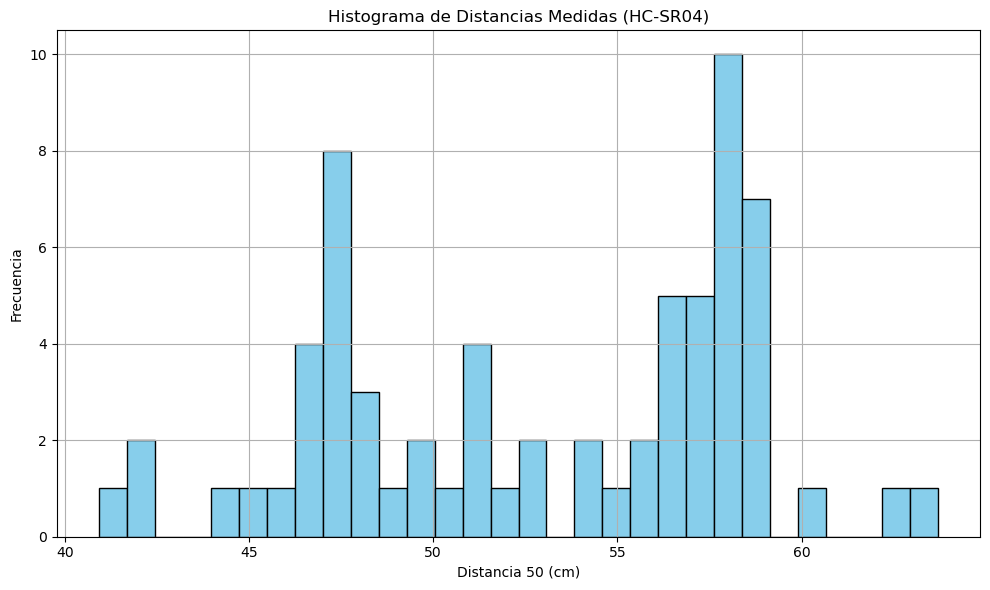

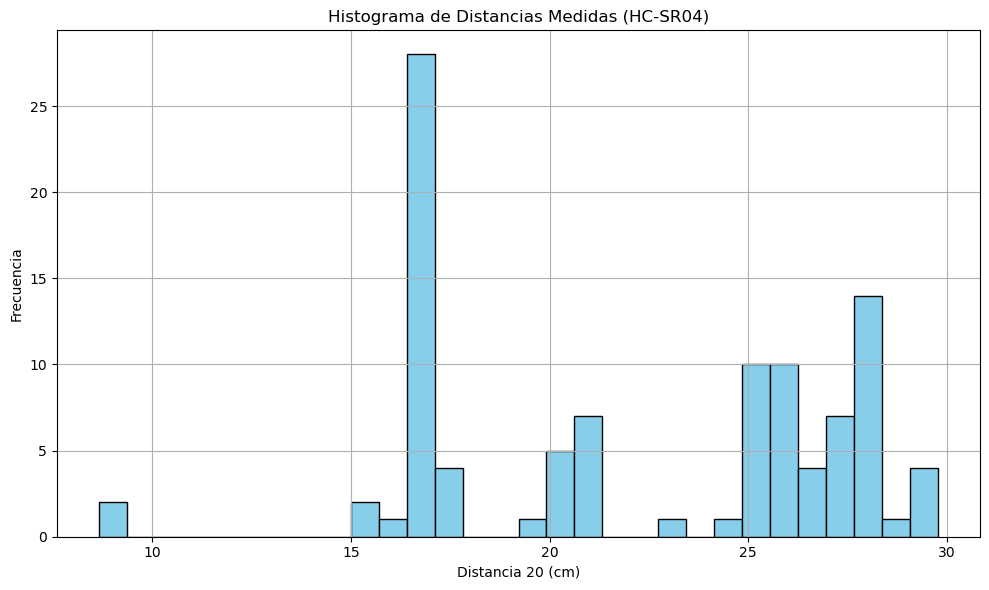

In [13]:
distances = data_1["distance_cm"]
# Crear histograma
plt.figure(figsize=(10, 6))
distances_1 = data_1["distance_cm"]
plt.hist(distances_1, bins=30, color='skyblue', edgecolor='black')
plt.title("Histograma de Distancias Medidas (HC-SR04)")
plt.xlabel("Distancia 50 (cm)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()

#histograma segunda data

distances = data_2["distance_cm"]
plt.figure(figsize=(10, 6))
distances_2 = data_2["distance_cm"]
plt.hist(distances_2, bins=30, color='skyblue', edgecolor='black')
plt.title("Histograma de Distancias Medidas (HC-SR04)")
plt.xlabel("Distancia 20 (cm)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()


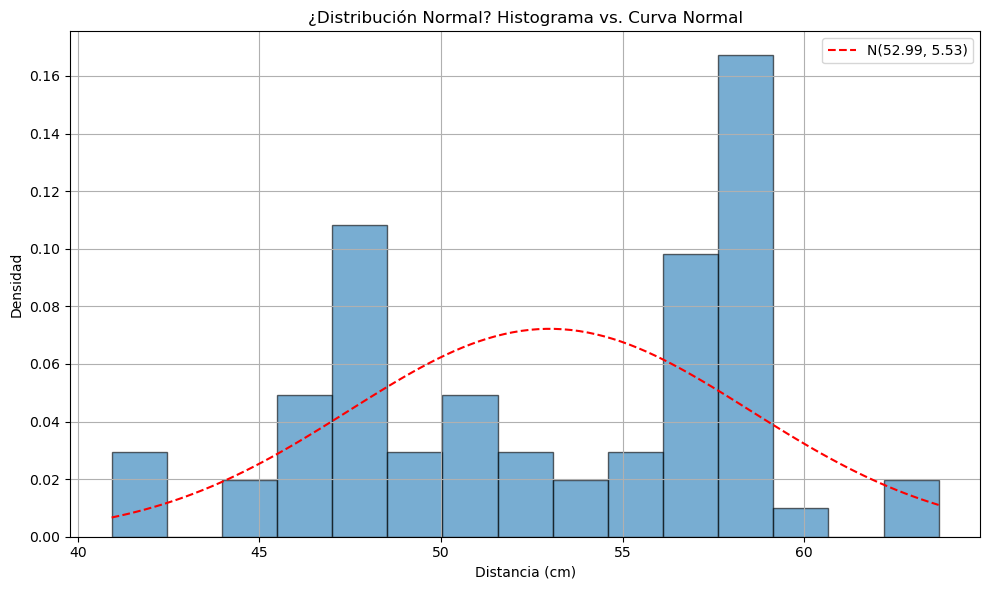

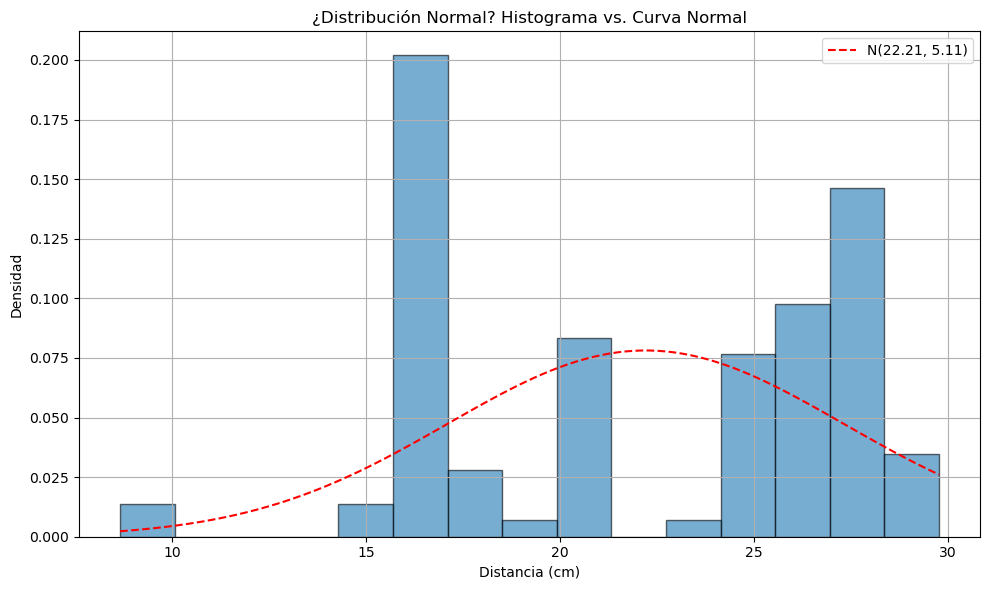

In [15]:
mean_1= distances_1.mean()
std_1 = distances_1.std()

plt.figure(figsize=(10, 6))
count, bins, ignored = plt.hist(distances_1, bins=15, density=True, alpha=0.6, edgecolor='black')

# Curva normal ajustada
x = np.linspace(min(distances_1), max(distances_1), 100)
plt.plot(x, norm.pdf(x, mean_1, std_1), 'r--', label=f'N({mean_1:.2f}, {std_1:.2f})')

plt.title("¿Distribución Normal? Histograma vs. Curva Normal")
plt.xlabel("Distancia (cm)")
plt.ylabel("Densidad")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


mean_2= distances_2.mean()
std_2 = distances_2.std()

plt.figure(figsize=(10, 6))
count, bins, ignored = plt.hist(distances_2, bins=15, density=True, alpha=0.6, edgecolor='black')

# Curva normal ajustada
x = np.linspace(min(distances_2), max(distances_2), 100)
plt.plot(x, norm.pdf(x, mean_2, std_2), 'r--', label=f'N({mean_2:.2f}, {std_2:.2f})')

plt.title("¿Distribución Normal? Histograma vs. Curva Normal")
plt.xlabel("Distancia (cm)")
plt.ylabel("Densidad")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Gráfica Q-Q (Quantile-Quantile)
Muestra si los cuantiles de tus datos se alinean con los de una distribución normal.
Si los puntos siguen la línea recta central tus datos se distribuyen normalmente.

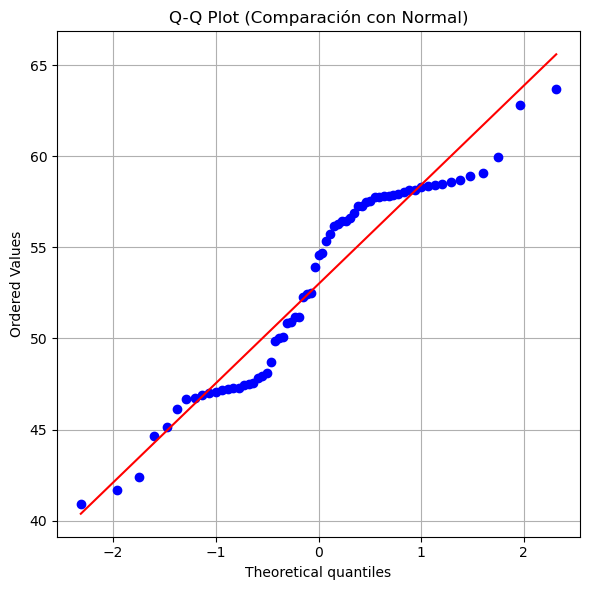

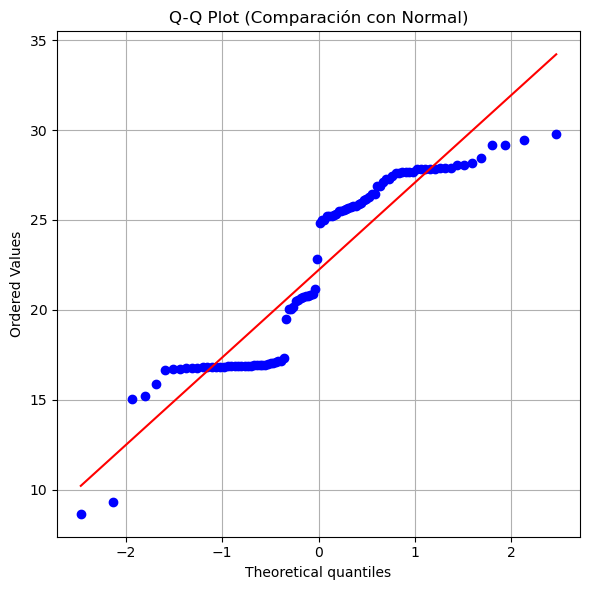

In [17]:
# Q-Q plot
plt.figure(figsize=(6, 6))
stats.probplot(distances_1, dist="norm", plot=plt)
plt.title("Q-Q Plot (Comparación con Normal)")
plt.grid(True)
plt.tight_layout()
plt.show()

# segunda data
plt.figure(figsize=(6, 6))
stats.probplot(distances_2, dist="norm", plot=plt)
plt.title("Q-Q Plot (Comparación con Normal)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
## Estadísticas
mean_1 = distances_1.mean()
std_1 = distances_1.std()
sem_1 = std_1 / (len(distances_1)**0.5)

print(f"Media (μ): {mean_1:.2f} cm")
print(f"Desviación estándar (σ): {std_1:.2f} cm")
print(f"Incertidumbre estándar (SEM): {sem_1:.2f} cm")

#segunda data

mean_2 = distances_2.mean()
std_2 = distances_2.std()
sem_2 = std_2 / (len(distances_2)**0.5)

print(f"Media (μ): {mean_2:.2f} cm")
print(f"Desviación estándar (σ): {std_2:.2f} cm")
print(f"Incertidumbre estándar (SEM): {sem_2:.2f} cm")


Media (μ): 52.99 cm
Desviación estándar (σ): 5.53 cm
Incertidumbre estándar (SEM): 0.68 cm
Media (μ): 22.21 cm
Desviación estándar (σ): 5.11 cm
Incertidumbre estándar (SEM): 0.51 cm


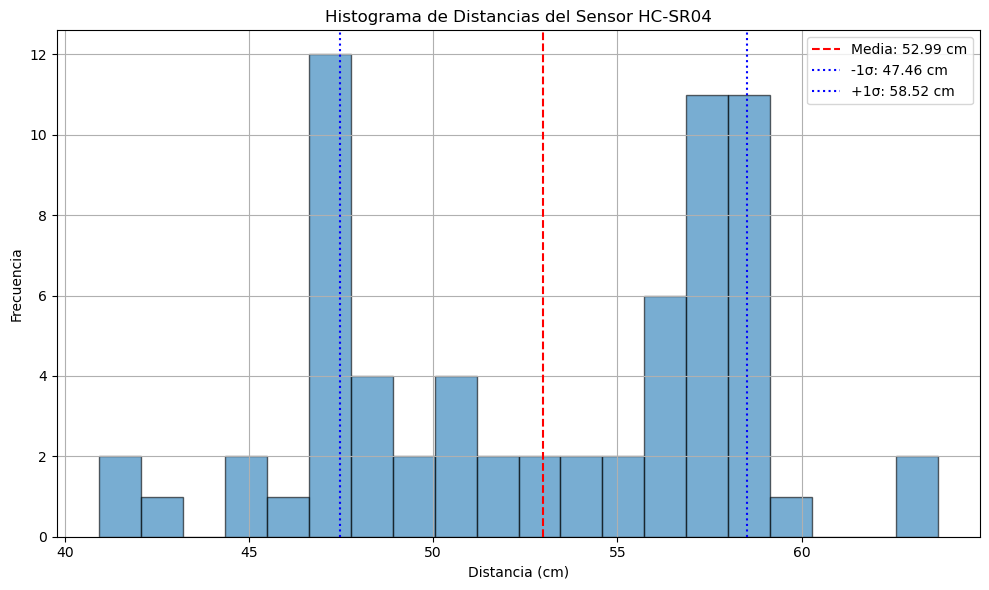

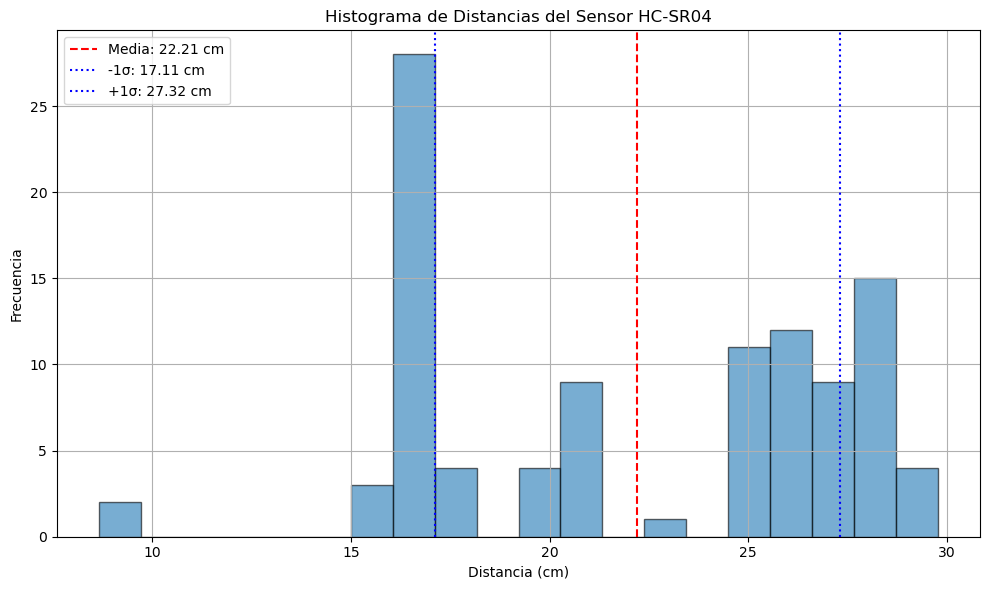

In [23]:
# Gráfico
plt.figure(figsize=(10, 6))
plt.hist(distances_1, bins=20, edgecolor='black', alpha=0.6)

#######################
plt.axvline(mean_1, color='red', linestyle='--', label=f'Media: {mean_1:.2f} cm')
plt.axvline(mean_1 - std_1, color='blue', linestyle=':', label=f'-1σ: {mean_1 - std_1:.2f} cm')
plt.axvline(mean_1 + std_1, color='blue', linestyle=':', label=f'+1σ: {mean_1 + std_1:.2f} cm')

# Estilo del gráfico
plt.title("Histograma de Distancias del Sensor HC-SR04")
plt.xlabel("Distancia (cm)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


#segunda data


# Gráfico
plt.figure(figsize=(10, 6))
plt.hist(distances_2, bins=20, edgecolor='black', alpha=0.6)

#######################
plt.axvline(mean_2, color='red', linestyle='--', label=f'Media: {mean_2:.2f} cm')
plt.axvline(mean_2 - std_2, color='blue', linestyle=':', label=f'-1σ: {mean_2 - std_2:.2f} cm')
plt.axvline(mean_2 + std_2, color='blue', linestyle=':', label=f'+1σ: {mean_2 + std_2:.2f} cm')

# Estilo del gráfico
plt.title("Histograma de Distancias del Sensor HC-SR04")
plt.xlabel("Distancia (cm)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Calculo del error

In [24]:
true_distance_1 = 50  # distancia real conocida
distances_1 = data_1["distance_cm"]
errors_1 = np.abs(distances_1 - true_distance_1)

mae_1 = np.mean(errors_1)
std_1 = np.std(distances_1, ddof=1)

print(f"Distancia real: {true_distance_1} cm")
print(f"Error medio absoluto (MAE): {mae_1:.3f} cm")
print(f"Desviación estándar: {std_1:.3f} cm")


true_distance_2 = 20  # distancia real conocida
distances_2 = data_2["distance_cm"]
errors_2 = np.abs(distances_2 - true_distance_2)

mae_2 = np.mean(errors_2)
std_2 = np.std(distances_2, ddof=1)

print(f"Distancia real: {true_distance_2} cm")
print(f"Error medio absoluto (MAE): {mae_2:.3f} cm")
print(f"Desviación estándar: {std_2:.3f} cm")

Distancia real: 50 cm
Error medio absoluto (MAE): 5.399 cm
Desviación estándar: 5.526 cm
Distancia real: 20 cm
Error medio absoluto (MAE): 4.870 cm
Desviación estándar: 5.106 cm


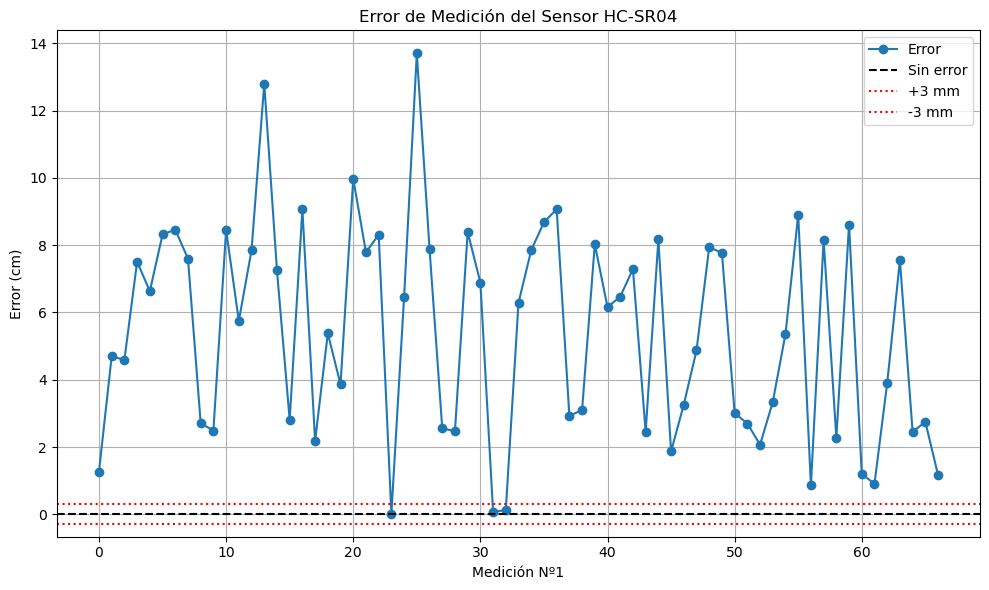

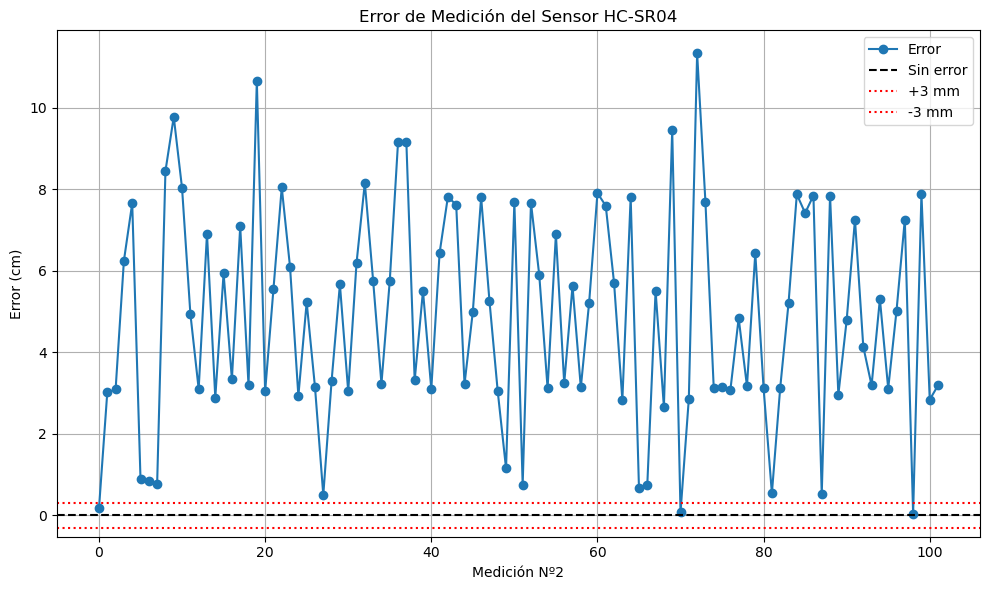

In [27]:
plt.figure(figsize=(10, 6))
plt.plot(errors_1.values, marker='o', linestyle='-', label="Error")
plt.axhline(0, color='black', linestyle='--', label="Sin error")
plt.axhline(0.3, color='red', linestyle=':', label="+3 mm")
plt.axhline(-0.3, color='red', linestyle=':', label="-3 mm")

plt.title("Error de Medición del Sensor HC-SR04")
plt.xlabel("Medición Nº1")
plt.ylabel("Error (cm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
plt.plot(errors_2.values, marker='o', linestyle='-', label="Error")
plt.axhline(0, color='black', linestyle='--', label="Sin error")
plt.axhline(0.3, color='red', linestyle=':', label="+3 mm")
plt.axhline(-0.3, color='red', linestyle=':', label="-3 mm")

plt.title("Error de Medición del Sensor HC-SR04")
plt.xlabel("Medición Nº2")
plt.ylabel("Error (cm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

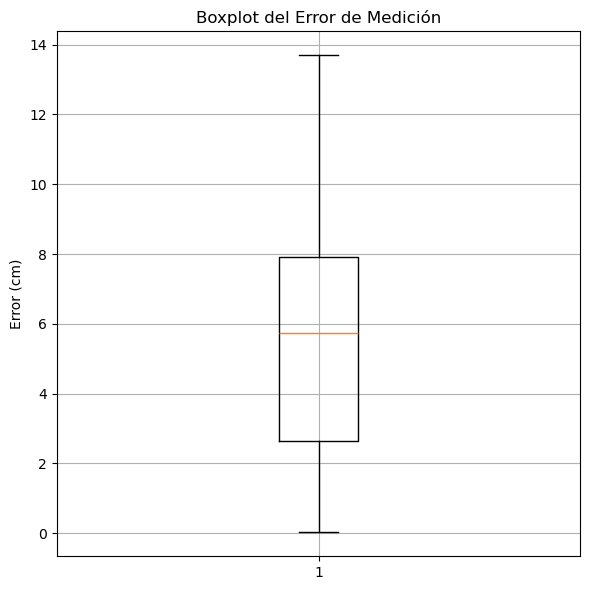

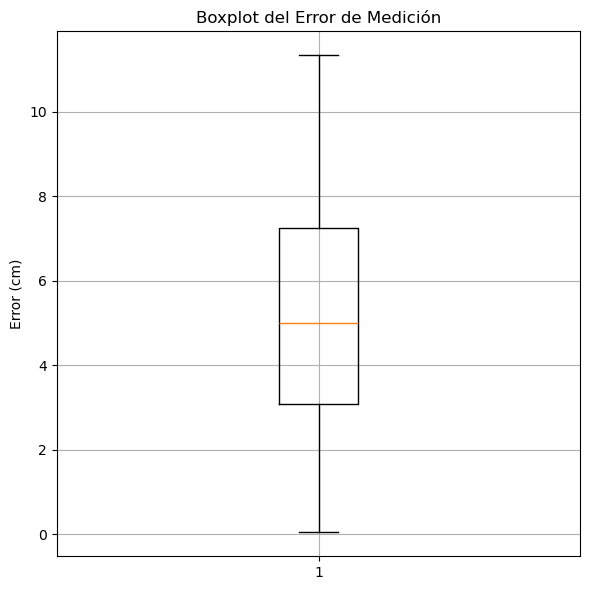

In [31]:
plt.figure(figsize=(6, 6))
plt.boxplot(errors_1, vert=True)

plt.title("Boxplot del Error de Medición")
plt.ylabel("Error (cm)")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.boxplot(errors_2, vert=True)

plt.title("Boxplot del Error de Medición")
plt.ylabel("Error (cm)")
plt.grid(True)
plt.tight_layout()
plt.show()

## Intervalo de confianza

$$
\text{ME} = z \cdot \frac{\sigma}{\sqrt{n}}
$$

- ME es el margen de error.

- z es el valor crítico (por ejemplo, 1.96 para un 95% de confianza).

- σ es la desviación estándar muestral.

- n es el tamaño de la muestra.

In [32]:
# Media y desviación estándar ya calculadas antes
mean_1 = distances_1.mean()
std_1 = distances_1.std(ddof=1)
n_1 = len(distances_1)

# Z-score para 95% de confianza
z = norm.ppf(0.975)

# Margen de error
me_1 = z * (std_1 / np.sqrt(n_1))

# Intervalo de confianza
ci_lower_1 = mean_1 - me_1
ci_upper_1 = mean_1 + me_1

print(f"Media: {mean_1:.2f} cm")
print(f"Desviación estándar: {std_1:.2f} cm")
print(f"N: {n_1}")
print(f"Margen de error (95%): ±{me_1:.2f} cm")
print(f"Intervalo de confianza al 95%: [{ci_lower_1:.2f} cm, {ci_upper_1:.2f} cm]")



# Media y desviación estándar ya calculadas antes
mean_2 = distances_2.mean()
std_2 = distances_2.std(ddof=1)
n_2 = len(distances_2)

# Z-score para 95% de confianza (ya definido antes como z)

# Margen de error
me_2 = z * (std_2 / np.sqrt(n_2))

# Intervalo de confianza
ci_lower_2 = mean_2 - me_2
ci_upper_2 = mean_2 + me_2

print(f"Media: {mean_2:.2f} cm")
print(f"Desviación estándar: {std_2:.2f} cm")
print(f"N: {n_2}")
print(f"Margen de error (95%): ±{me_2:.2f} cm")
print(f"Intervalo de confianza al 95%: [{ci_lower_2:.2f} cm, {ci_upper_2:.2f} cm]")


Media: 52.99 cm
Desviación estándar: 5.53 cm
N: 67
Margen de error (95%): ±1.32 cm
Intervalo de confianza al 95%: [51.67 cm, 54.31 cm]
Media: 22.21 cm
Desviación estándar: 5.11 cm
N: 102
Margen de error (95%): ±0.99 cm
Intervalo de confianza al 95%: [21.22 cm, 23.20 cm]
